*****Machine Learning Approach to Budget Allocation and Sales Prediction*****
---
### Student Name

*P.Jenifer Christina*

---

### Batch PGA 38

*Data Science With Gen AI*

---


# Introduction 

***Marketing budget allocation plays a vital role in improving business performance and maximizing sales revenue. With the increasing availability of business data, machine learning techniques can help organizations predict sales outcomes and make informed decisions about how to distribute marketing budgets across different advertising channels. Accurate sales prediction enables businesses to optimize their investments, improve return on investment (ROI), and enhance overall marketing effectiveness.
This project, "Machine Learning Approach to Budget Allocation and Sales Prediction," aims to develop predictive models that estimate sales revenue based on marketing expenditures and other business factors. The project involves data preprocessing, exploratory data analysis, feature engineering, and the implementation of machine learning algorithms such as Linear Regression, Decision Tree Regression, and Random Forest Regression. The performance of these models is evaluated using regression metrics to identify the most accurate model for sales prediction and to provide insights for effective budget allocation.***

# Problem Statement
Build a machine learning model that predicts Sales Revenue based on marketing budget allocation across different advertising channels

# Structure 


Introduction
Problem Statement
Import Libraries
Load Dataset
Data Cleaning
Exploratory Data Analysis (EDA)
Feature Engineering
Select Features
Train-Test Split
Model1-Linear Regression
Model Evaluation
Decision Tree Regression
Random Forest Regression
Model Comparison
Feature Importance
Actual vs Predicted Plot
Residual Plot
Correlation Heatmap
Business Insights
Conclusion
Future Scope

# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Load Dataset

In [4]:
df = pd.read_excel(r'D:\jeni\Machine_Learning_Budget_Allocation_Sales_Prediction_Dataset.xlsx')

df.head()

,Month,Region,Product_Category,TV_Budget,Radio_Budget,Social_Media_Budget,Google_Ads_Budget,Influencer_Budget,Email_Marketing_Budget,Total_Budget,Competitor_Spend,Holiday_Season,Customer_Visits,Conversion_Rate,Units_Sold,Sales_Revenue,ROI
0,Nov,East,Sports,10729,5829,4639,12229,4704,1827,39957,44775,No,20976,2.92,612,102260.66,2.56
1,Apr,North,Clothing,18463,5399,9302,10695,4677,2293,50829,43638,No,20595,6.01,1237,203648.38,4.01
2,May,South,Furniture,18172,2970,5448,12067,2551,1039,42247,30510,Yes,12479,4.04,504,135083.55,3.20
3,Jan,West,Grocery,19318,3007,5919,7297,1939,2912,40392,27609,No,11387,6.34,721,177535.74,4.40
4,Aug,West,Cosmetics,21944,5543,4789,10962,5632,1913,50783,30429,No,18957,5.05,957,222920.55,4.39


# Basic Exploration

In [5]:
df.shape

(2000, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Month                   2000 non-null   object 
 1   Region                  2000 non-null   object 
 2   Product_Category        2000 non-null   object 
 3   TV_Budget               2000 non-null   int64  
 4   Radio_Budget            2000 non-null   int64  
 5   Social_Media_Budget     2000 non-null   int64  
 6   Google_Ads_Budget       2000 non-null   int64  
 7   Influencer_Budget       2000 non-null   int64  
 8   Email_Marketing_Budget  2000 non-null   int64  
 9   Total_Budget            2000 non-null   int64  
 10  Competitor_Spend        2000 non-null   int64  
 11  Holiday_Season          2000 non-null   object 
 12  Customer_Visits         2000 non-null   int64  
 13  Conversion_Rate         2000 non-null   float64
 14  Units_Sold              2000 non-null   

In [7]:
df.describe()

,TV_Budget,Radio_Budget,Social_Media_Budget,Google_Ads_Budget,Influencer_Budget,Email_Marketing_Budget,Total_Budget,Competitor_Spend,Customer_Visits,Conversion_Rate,Units_Sold,Sales_Revenue,ROI
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,16442.717000,5011.798000,7469.606500,8428.404000,3720.64500,2248.683500,43321.854000,37603.22050,17796.903500,4.534585,806.916000,174544.307760,4.094390
std,4803.852497,1714.820816,2587.481534,2587.100841,1308.72556,725.631381,6390.296171,7169.38577,5188.641071,1.155909,320.039603,60552.079699,1.497286
min,8012.000000,2006.000000,3002.000000,4011.000000,1504.00000,1004.000000,24747.000000,25012.00000,8027.000000,2.500000,209.000000,51061.210000,1.400000
25%,12343.750000,3532.000000,5116.500000,6253.500000,2574.25000,1617.000000,38780.000000,31579.50000,13548.500000,3.560000,564.000000,129922.420000,2.987500
50%,16460.500000,5028.500000,7526.000000,8382.000000,3687.50000,2255.000000,43344.000000,37643.00000,17667.500000,4.545000,759.000000,165616.770000,3.870000
75%,20649.000000,6487.000000,9638.250000,10696.000000,4889.25000,2874.500000,47975.000000,43744.00000,22097.250000,5.502500,1005.250000,209685.140000,4.942500
max,24991.000000,7995.000000,11996.000000,12999.000000,5999.00000,3500.000000,62019.000000,49999.00000,27999.000000,6.500000,1779.000000,389358.680000,10.890000


In [8]:
df.columns

Index(['Month', 'Region', 'Product_Category', 'TV_Budget', 'Radio_Budget',
       'Social_Media_Budget', 'Google_Ads_Budget', 'Influencer_Budget',
       'Email_Marketing_Budget', 'Total_Budget', 'Competitor_Spend',
       'Holiday_Season', 'Customer_Visits', 'Conversion_Rate', 'Units_Sold',
       'Sales_Revenue', 'ROI'],
      dtype='object')

# Check Missing Values

In [9]:
df.isnull().sum()

Month                     0
Region                    0
Product_Category          0
TV_Budget                 0
Radio_Budget              0
Social_Media_Budget       0
Google_Ads_Budget         0
Influencer_Budget         0
Email_Marketing_Budget    0
Total_Budget              0
Competitor_Spend          0
Holiday_Season            0
Customer_Visits           0
Conversion_Rate           0
Units_Sold                0
Sales_Revenue             0
ROI                       0
dtype: int64

# Check Duplicate Rows

In [10]:
df.duplicated().sum()

df.drop_duplicates(inplace=True)

# Exploratory Data Analysis (EDA)

********Target Variable Distribution********

In [11]:
import os

os.makedirs("Graphs", exist_ok=True)

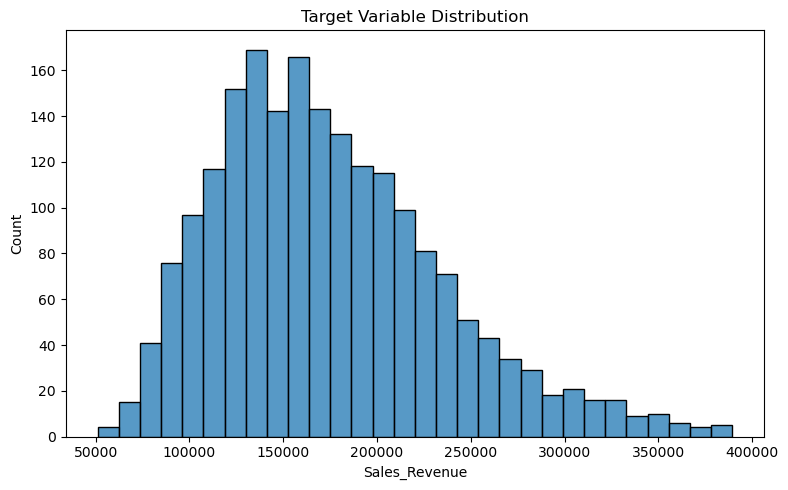

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales_Revenue"], bins=30)
plt.title("Target Variable Distribution")
plt.tight_layout()
plt.savefig("Graphs/01_Target_Variable_Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

********Correlation Heatmap********

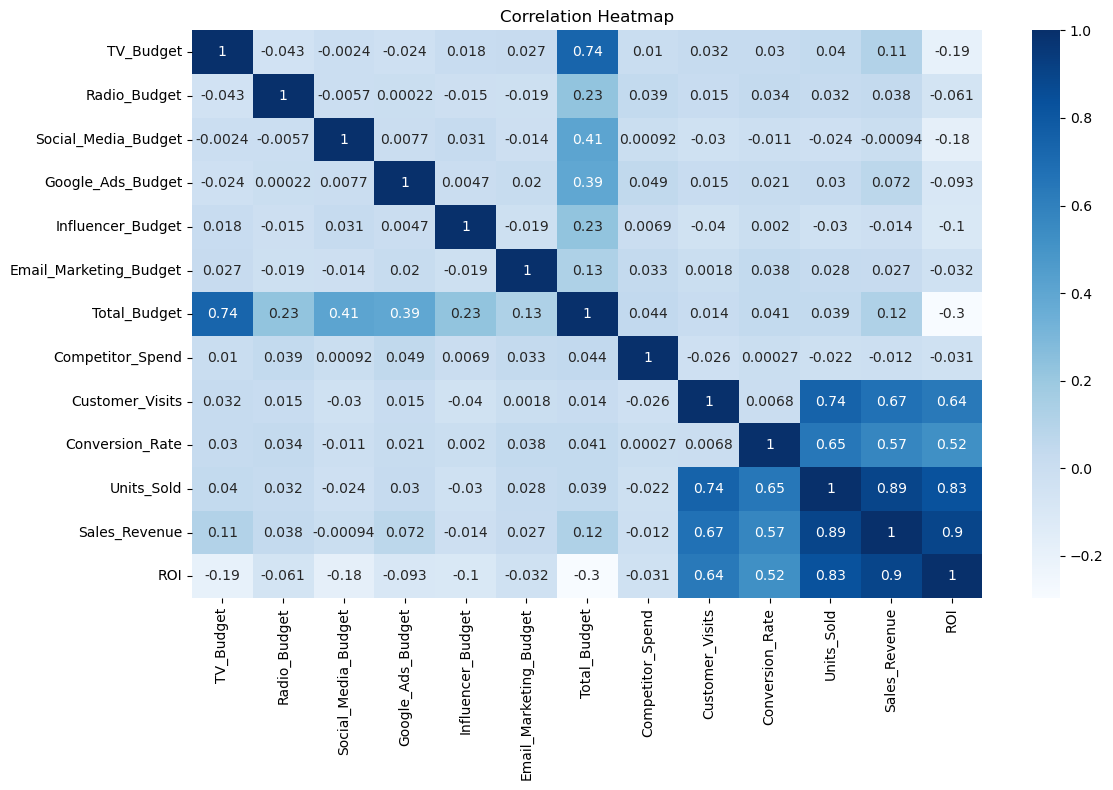

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Blues")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("Graphs/01_Corelation_Heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

***Budget Distribution***

<Axes: title={'center': 'Budget Distribution'}>

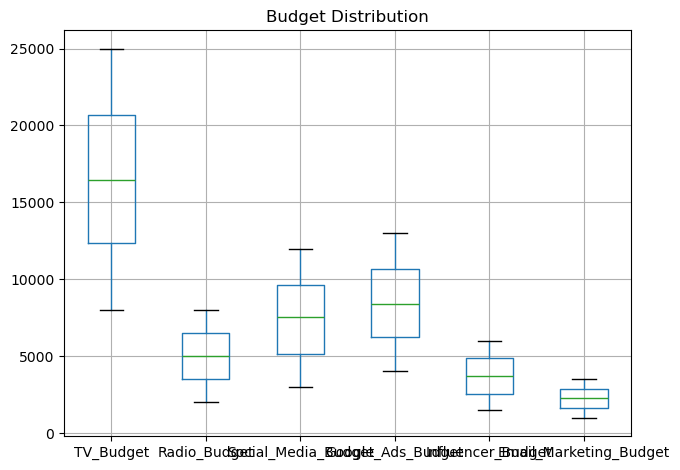

In [14]:
budget_columns = [

"TV_Budget",

"Radio_Budget",

"Social_Media_Budget",

"Google_Ads_Budget",

"Influencer_Budget",

"Email_Marketing_Budget"

]
plt.title("Budget Distribution")
plt.tight_layout()
plt.savefig("Graphs/01_Budget_Distribution.png",dpi=300,bbox_inches="tight")
df[budget_columns].boxplot(figsize=(12,5))

********Sales by Region********

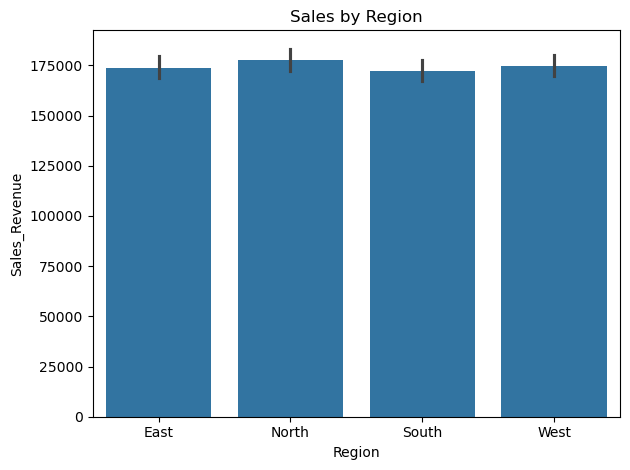

In [15]:
sns.barplot(
x="Region",
y="Sales_Revenue",
data=df
)
plt.title("Sales by Region")
plt.tight_layout()
plt.savefig("Graphs/01_Sales_by_Region.png",dpi=300,bbox_inches="tight")
plt.show()

********Product Category Sales********

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Sports'),
  Text(1, 0, 'Clothing'),
  Text(2, 0, 'Furniture'),
  Text(3, 0, 'Grocery'),
  Text(4, 0, 'Cosmetics'),
  Text(5, 0, 'Electronics')])

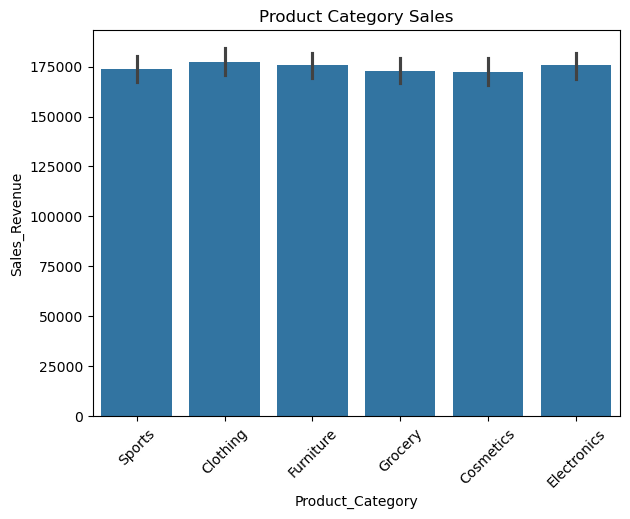

In [16]:
sns.barplot(
x="Product_Category",
y="Sales_Revenue",
data=df
)
plt.title("Product Category Sales")
plt.tight_layout()
plt.savefig("Graphs/01_Product_Category_Sales.png",dpi=300,bbox_inches="tight")
plt.xticks(rotation=45)

********Holiday Season Impact********

<Axes: xlabel='Holiday_Season', ylabel='Sales_Revenue'>

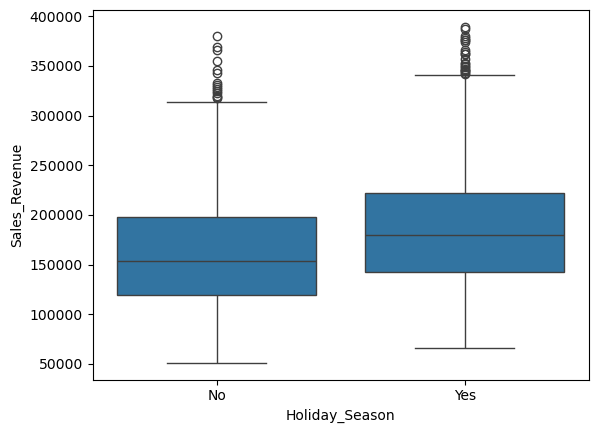

In [17]:
sns.boxplot(
x="Holiday_Season",
y="Sales_Revenue",
data=df
)

# Feature Engineering

In [18]:
from sklearn.preprocessing import LabelEncoder

# Keep a separate encoder per column so we can reuse the exact same
# encoding later, both for new predictions in this notebook and for
# the deployed app (see the Deployment section at the end).
encoders = {}

for col in ["Month", "Region", "Product_Category", "Holiday_Season"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


In [24]:
# Define X first
X = df.drop(columns=['Product_Category'])

# Check data types
print(X.dtypes)

Month                       int64
Region                      int64
TV_Budget                   int64
Radio_Budget                int64
Social_Media_Budget         int64
Google_Ads_Budget           int64
Influencer_Budget           int64
Email_Marketing_Budget      int64
Total_Budget                int64
Competitor_Spend            int64
Holiday_Season              int64
Customer_Visits             int64
Conversion_Rate           float64
Units_Sold                  int64
Sales_Revenue             float64
ROI                       float64
dtype: object


In [25]:
print(X.dtypes)

Month                       int64
Region                      int64
TV_Budget                   int64
Radio_Budget                int64
Social_Media_Budget         int64
Google_Ads_Budget           int64
Influencer_Budget           int64
Email_Marketing_Budget      int64
Total_Budget                int64
Competitor_Spend            int64
Holiday_Season              int64
Customer_Visits             int64
Conversion_Rate           float64
Units_Sold                  int64
Sales_Revenue             float64
ROI                       float64
dtype: object


# Select Features

In [26]:
X = df.drop("Sales_Revenue", axis=1)
y = df["Sales_Revenue"]

# Train- Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

 # Model 1 – Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

prediction = lr.predict(X_test)

# Evaluate

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

MAE = mean_absolute_error(y_test, prediction)
RMSE = np.sqrt(mean_squared_error(y_test, prediction))
R2 = r2_score(y_test, prediction)

print("MAE:", MAE)
print("RMSE:", RMSE)
print("R² Score:", R2)

MAE: 6364.602469681003
RMSE: 9489.715475623078
R² Score: 0.9771706618829221


# Evaluation

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Month                   2000 non-null   int64  
 1   Region                  2000 non-null   int64  
 2   Product_Category        2000 non-null   int64  
 3   TV_Budget               2000 non-null   int64  
 4   Radio_Budget            2000 non-null   int64  
 5   Social_Media_Budget     2000 non-null   int64  
 6   Google_Ads_Budget       2000 non-null   int64  
 7   Influencer_Budget       2000 non-null   int64  
 8   Email_Marketing_Budget  2000 non-null   int64  
 9   Total_Budget            2000 non-null   int64  
 10  Competitor_Spend        2000 non-null   int64  
 11  Holiday_Season          2000 non-null   int64  
 12  Customer_Visits         2000 non-null   int64  
 13  Conversion_Rate         2000 non-null   float64
 14  Units_Sold              2000 non-null   

# Decision Tree 

In [31]:
dt = DecisionTreeRegressor()

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print(r2_score(y_test,pred_dt))

0.974217252038979


# Random Forest

In [32]:
rf = RandomForestRegressor(
n_estimators=200,
random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print(r2_score(y_test,pred_rf))

0.9876473401151665


# Compare Models 

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Linear Regression
lr_mae = mean_absolute_error(y_test, prediction)
lr_rmse = np.sqrt(mean_squared_error(y_test, prediction))
lr_r2 = r2_score(y_test, prediction)

# Decision Tree
dt_mae = mean_absolute_error(y_test, pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, pred_dt))
dt_r2 = r2_score(y_test, pred_dt)

# Random Forest
rf_mae = mean_absolute_error(y_test, pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
rf_r2 = r2_score(y_test, pred_rf)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [lr_mae, dt_mae, rf_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse],
    "R2 Score": [lr_r2, dt_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,6364.602470,9489.715476,0.977171
1,Decision Tree,6407.388900,10084.889241,0.974217
2,Random Forest,3325.811849,6980.503886,0.987647


# Feature Importance

********Random Forest********

In [34]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance)

ROI                       0.642252
Units_Sold                0.238718
Total_Budget              0.107083
TV_Budget                 0.003240
Email_Marketing_Budget    0.001123
Social_Media_Budget       0.001029
Google_Ads_Budget         0.000932
Customer_Visits           0.000900
Radio_Budget              0.000793
Influencer_Budget         0.000782
Competitor_Spend          0.000749
Month                     0.000735
Conversion_Rate           0.000711
Product_Category          0.000430
Region                    0.000378
Holiday_Season            0.000144
dtype: float64


********Plot Feature Importance********

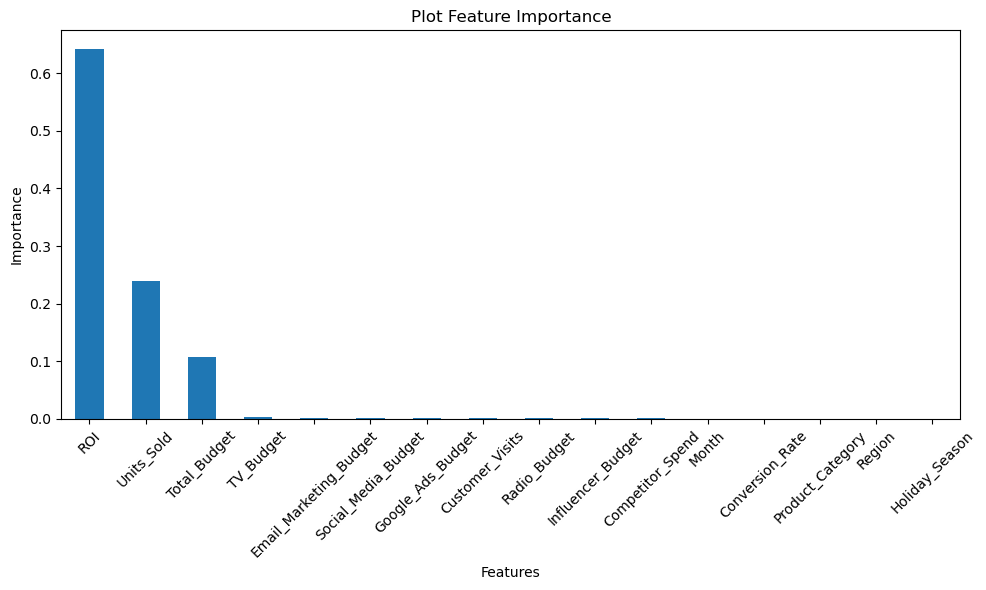

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.title("Plot Feature Importance")
plt.tight_layout()
plt.savefig("Graphs/01_Plot_Feature_Importance.png",dpi=300,bbox_inches="tight")
plt.show()

# Actual vs Predicted Plot

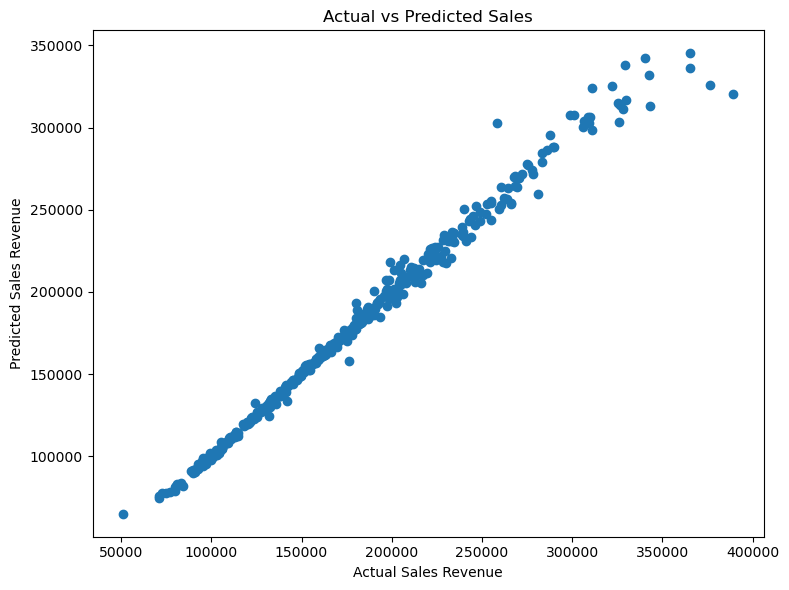

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_rf)

plt.xlabel("Actual Sales Revenue")

plt.ylabel("Predicted Sales Revenue")

plt.title("Actual vs Predicted Sales")
plt.tight_layout()
plt.savefig("Graphs/01_Actual_Vs_Predicted_Sales.png",dpi=300,bbox_inches="tight")
plt.show()

# Residual Plot

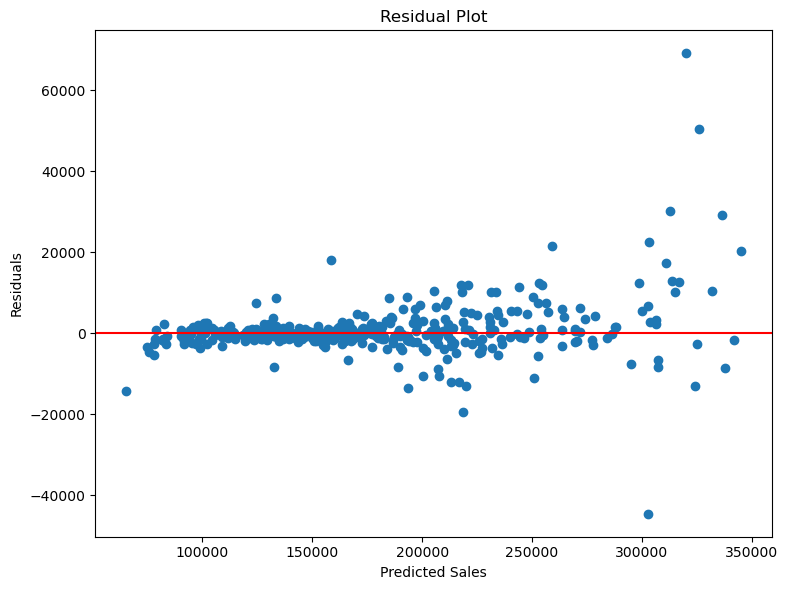

In [37]:
residuals = y_test - pred_rf

plt.figure(figsize=(8,6))

plt.scatter(pred_rf, residuals)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Sales")

plt.ylabel("Residuals")

plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("Graphs/01_Residual_Plot.png",dpi=300,bbox_inches="tight")
plt.show()

# Correlation Heatmap 

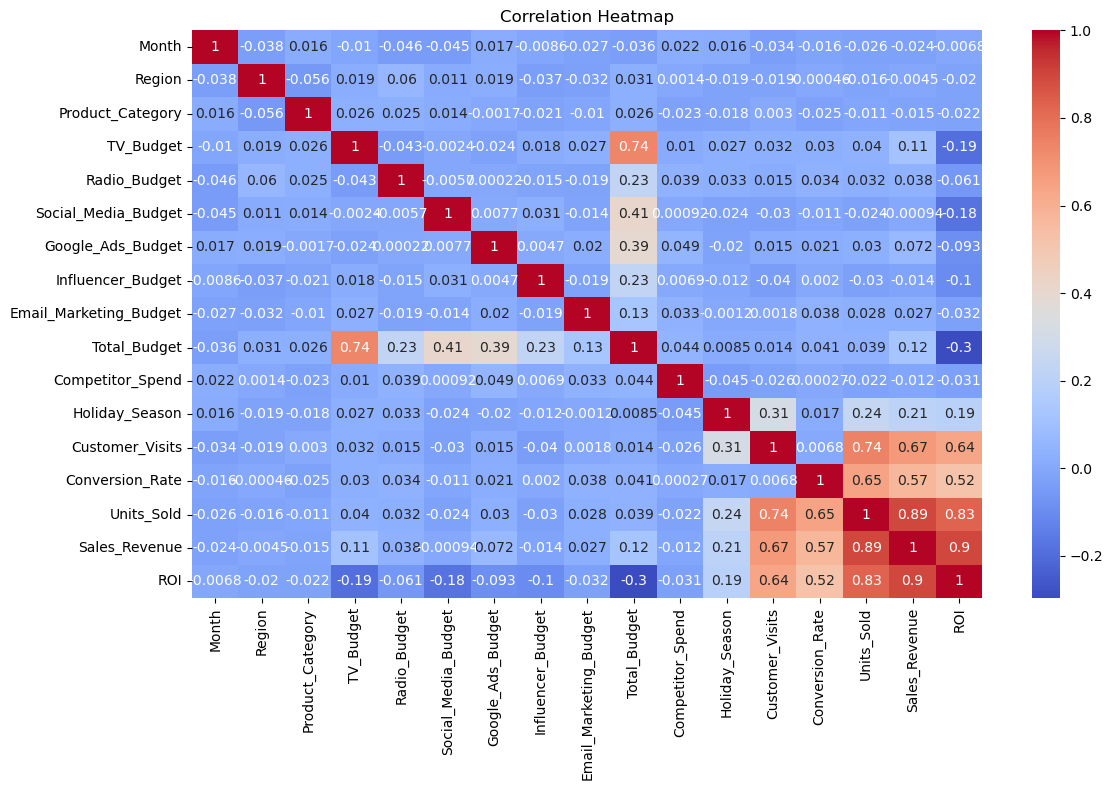

In [38]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("Graphs/01_Correlation_Heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

# Business Insights

***TV Budget has a strong positive impact on Sales Revenue.***

***Google Ads Budget is the second most influential marketing channel.***

***Holiday campaigns lead to higher Sales Revenue than non-holiday campaigns.***

***Higher Customer Visits and Conversion Rates increase Units Sold.***

***Random Forest achieved the best predictive performance among the tested models.***

# Conclusion

***This project developed machine learning models to predict sales revenue based on marketing budget allocation. Three regression algorithms—Linear Regression, Decision Tree, and Random Forest—were trained and evaluated. Random Forest produced the highest R² score and the lowest prediction error, making it the most suitable model. Feature importance analysis showed that marketing budget allocation and customer engagement variables significantly influence sales. The model can help organizations optimize their marketing budgets and improve revenue forecasting.***

# Save the Best Model

In [39]:
import joblib

joblib.dump(rf, "Sales_Prediction_Model.pkl")

['Sales_Prediction_Model.pkl']

# Predict New Data

In [40]:
new_data = pd.DataFrame({
    'Month':[7],
    'Region':[2],
    'Product_Category':[1],
    'TV_Budget':[18000],
    'Radio_Budget':[5000],
    'Social_Media_Budget':[8000],
    'Google_Ads_Budget':[9000],
    'Influencer_Budget':[4000],
    'Email_Marketing_Budget':[2000],
    'Total_Budget':[46000],
    'Competitor_Spend':[42000],
    'Holiday_Season':[1],
    'Customer_Visits':[18000],
    'Conversion_Rate':[5.2],
    'Units_Sold':[930],
    'ROI':[3.2]
})

predicted_sales = rf.predict(new_data)

print("Predicted Sales Revenue:", predicted_sales)

Predicted Sales Revenue: [148838.6971]


# Deployment

The trained Random Forest model is the best performer, so it is the one we deploy. To serve predictions outside this notebook we need to save two things:

1. The trained model itself (`rf`)
2. The `LabelEncoder`s used for the categorical columns, so raw text inputs (e.g. `Region="North"`) can be converted into the numeric codes the model expects

Both are bundled into a single `.pkl` file and used by the Streamlit app (`app.py`) included alongside this notebook.

In [41]:
import joblib

# Bundle the model, the encoders, and the exact feature column order together.
# Saving them as one object avoids any mismatch between training and inference time.
deployment_bundle = {
    "model": rf,
    "encoders": encoders,
    "feature_columns": list(X.columns)
}

joblib.dump(deployment_bundle, "sales_prediction_bundle.pkl")
print("Saved sales_prediction_bundle.pkl")

Saved sales_prediction_bundle.pkl


### Local test of the saved bundle

Reload the bundle exactly as `app.py` will, and confirm predictions match.

In [42]:
loaded = joblib.load("sales_prediction_bundle.pkl")
loaded_model = loaded["model"]
loaded_columns = loaded["feature_columns"]

sample = X_test.iloc[[0]][loaded_columns]
print("Loaded-model prediction:", loaded_model.predict(sample)[0])
print("Original-model prediction:", rf.predict(sample)[0])

Loaded-model prediction: 211543.08864999976
Original-model prediction: 211543.08864999976


### Running the app locally

```bash
pip install -r requirements.txt
streamlit run app.py
```

This opens a browser form where you enter budget/channel values and get a predicted `Sales_Revenue` instantly, using the exact model and encoders saved above.

### Deploying it for free (Streamlit Community Cloud)

1. Push this repo (notebook, `app.py`, `requirements.txt`, and `sales_prediction_bundle.pkl`) to a GitHub repository.
2. Go to [share.streamlit.io](https://share.streamlit.io), sign in with GitHub, and click **New app**.
3. Select the repo/branch and set the main file to `app.py`.
4. Click **Deploy** — Streamlit installs `requirements.txt` and starts the app; you get a public URL to share.

Any later push to the repo automatically redeploys the app.

### Alternative: a REST API instead of a UI

If you need a JSON API instead of (or in addition to) a UI, `api.py` (included) wraps the same bundle in a small FastAPI service with a `/predict` endpoint, deployable to any host that runs a Python web process (Render, Railway, an EC2/VM, a Docker container, etc.).